# `revenue_diagnostic.py`

Phase 2 — Diagnostic: 15 chart (07-21) trả lời vì sao đằng sau 6 chart Descriptive (category/region/kênh/khuyến mãi qua các năm, break 2019 tách ASP vs khối lượng, cơ chế lỗ gộp, margin category×region kiểm soát mix, Tết×promo). Notebook chạy đúng code gốc, chart hiện inline.

In [1]:
%matplotlib inline
import os
os.chdir(r"/Users/lhoanghai_/Documents/Study/Dự án datathon2026")
__file__ = r"/Users/lhoanghai_/Documents/Study/Dự án datathon2026/EDA_Insight/phase2_diagnostic/revenue_diagnostic.py"  # notebook không có __file__ mặc định -> gán thủ công để mọi Path(__file__)... trong code gốc resolve đúng thư mục như khi chạy .py


## Thiết lập / import

In [2]:
# Diagnostic revenue — kết hợp orders + order_items + products + customers +
# geography + promotions + returns + payments để trả lời "vì sao" đằng sau
# 6 chart Descriptive đã có (eda_training_charts.py, phase1_descriptive/).
# Output: EDA_Insight/output/phase2/07..14_*.png + in số liệu ra console.
# Chạy: python EDA_Insight/phase2_diagnostic/revenue_diagnostic.py (sau khi activate .venv)

import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use("Agg")  # bỏ trong notebook để %matplotlib inline hiển thị chart
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path(__file__).resolve().parent           # EDA_Insight/phase2_diagnostic/
DATA = HERE.parent.parent / "data"                # dữ liệu gốc: <project root>/data
OUT = HERE.parent / "output" / "phase2"           # chart: EDA_Insight/output/phase2/
OUT.mkdir(parents=True, exist_ok=True)

C_REV, C_COGS, C_GRAY, C_ACCENT = "#A32D2D", "#185FA5", "#888780", "#534AB7"
PALETTE = ["#185FA5", "#A32D2D", "#3B6D11", "#BA7517", "#534AB7", "#993556"]

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

print("Đang load & join dữ liệu...")
orders = pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"])
items = pd.read_csv(DATA / "order_items.csv")
products = pd.read_csv(DATA / "products.csv", usecols=["product_id", "category", "cogs", "price"])
customers = pd.read_csv(DATA / "customers.csv", usecols=["customer_id", "acquisition_channel", "signup_date"])
geography = pd.read_csv(DATA / "geography.csv", usecols=["zip", "region"])
promotions = pd.read_csv(DATA / "promotions.csv",
                          usecols=["promo_id", "promo_type", "promo_channel", "discount_value",
                                   "start_date", "end_date"],
                          parse_dates=["start_date", "end_date"])
returns = pd.read_csv(DATA / "returns.csv", usecols=["order_id", "refund_amount"])
sales = pd.read_csv(DATA / "sales.csv", parse_dates=["Date"])

Đang load & join dữ liệu...


/var/folders/t9/tstf90y13wd9p_7gc7pf9htr0000gp/T/ipykernel_73354/1332279579.py:28: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  items = pd.read_csv(DATA / "order_items.csv")


## JOIN GỐC: order_items (grain = 1 dòng/sản phẩm/đơn) + mọi chiều liên quan

In [3]:
li = (items
      .merge(orders, on="order_id", how="left")
      .merge(products, on="product_id", how="left")
      .merge(customers, on="customer_id", how="left")
      .merge(geography, on="zip", how="left")
      .merge(promotions, on="promo_id", how="left"))

li["line_revenue"] = li["quantity"] * li["unit_price"]
li["line_cogs"] = li["quantity"] * li["cogs"]
li["year"] = li["order_date"].dt.year
li["month"] = li["order_date"].dt.month
li = li[li["year"].between(2013, 2022)].copy()  # bỏ nửa năm 2012 lẻ, đồng bộ các chart trước

# sanity check với sales.csv (Phase 0 đã xác nhận công thức)
chk = li.groupby(li["order_date"])["line_revenue"].sum()
diff = ((chk.reindex(sales.set_index("Date")["Revenue"].index) - sales.set_index("Date")["Revenue"]).abs()
        / sales.set_index("Date")["Revenue"]).mean() * 100
print(f"Sanity check — sai lệch rebuilt vs sales.csv: {diff:.3f}% (kỳ vọng ~0%)\n")

Sanity check — sai lệch rebuilt vs sales.csv: 0.000% (kỳ vọng ~0%)



## 07. REVENUE THEO CATEGORY — tỷ trọng đổi qua các năm

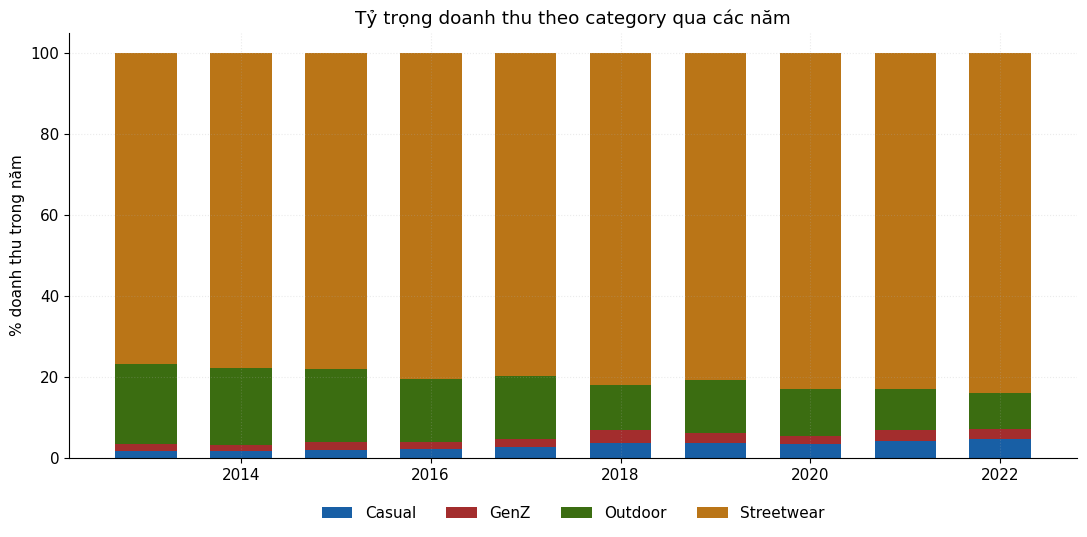

=== 07. Category ===
  2013: {'Casual': 1.8, 'GenZ': 1.6, 'Outdoor': 19.8, 'Streetwear': 76.8}
  2022: {'Casual': 4.6, 'GenZ': 2.5, 'Outdoor': 9.0, 'Streetwear': 83.8}



In [4]:
cat_yr = li.groupby(["year", "category"])["line_revenue"].sum().unstack()
cat_share = cat_yr.div(cat_yr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(cat_share))
for i, cat in enumerate(cat_share.columns):
    ax.bar(cat_share.index, cat_share[cat], bottom=bottom, label=cat,
           color=PALETTE[i % len(PALETTE)], width=0.65)
    bottom += cat_share[cat].values
ax.set_ylabel("% doanh thu trong năm")
ax.set_title("Tỷ trọng doanh thu theo category qua các năm")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(); fig.savefig(OUT / "07_category_share.png", dpi=110); plt.show(); plt.close(fig)

print("=== 07. Category ===")
print(f"  2013: {cat_share.loc[2013].round(1).to_dict()}")
print(f"  2022: {cat_share.loc[2022].round(1).to_dict()}\n")

**Phân tích chart 07 — Category share theo năm**

1. **Thể hiện gì:** tỷ trọng % doanh thu theo 4 category (Casual, GenZ, Outdoor, Streetwear) qua các năm 2013-2022.
2. **Insight:** Streetwear tăng từ 76.8% (2013) lên **83.8%** (2022); Outdoor mất hơn nửa tỷ trọng (19.8%→9.0%) trong 10 năm, Streetwear hút hết phần đó. Danh mục ngày càng lệ thuộc 1 category duy nhất — rủi ro tập trung.
3. **Lưu ý:** đây là % tỷ trọng (relative), không phải giá trị tuyệt đối — Outdoor "mất tỷ trọng" không chắc nghĩa là doanh thu Outdoor giảm tuyệt đối (có thể Streetwear tăng nhanh hơn che khuất); cần đối chiếu doanh thu tuyệt đối nếu muốn kết luận Outdoor có suy giảm thật hay không.


## 08. REVENUE THEO REGION

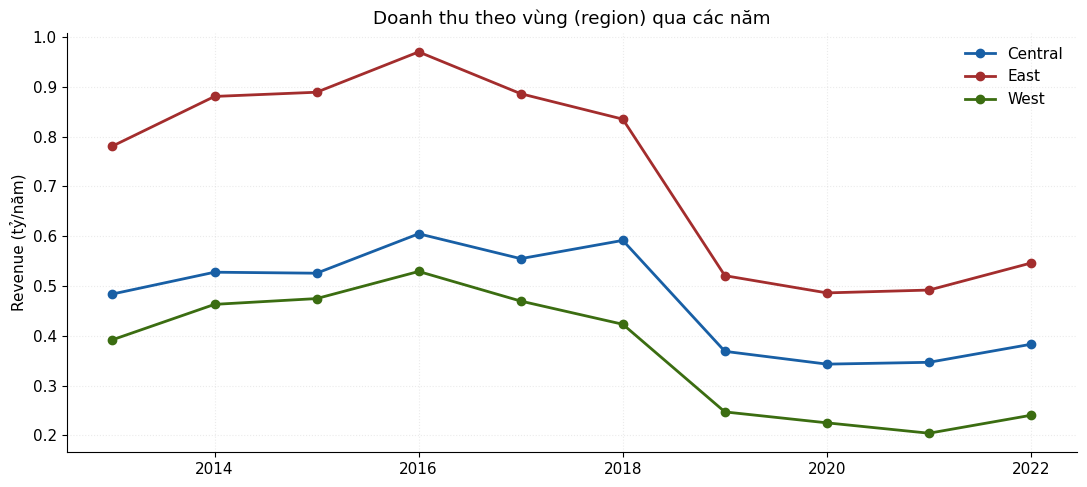

=== 08. Region (tỷ VND, 2022) ===
  {'Central': 0.4, 'East': 0.5, 'West': 0.2}



In [5]:
reg_yr = li.groupby(["year", "region"])["line_revenue"].sum().unstack() / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
for i, reg in enumerate(reg_yr.columns):
    ax.plot(reg_yr.index, reg_yr[reg], "o-", color=PALETTE[i % len(PALETTE)], lw=2, label=reg)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu theo vùng (region) qua các năm")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "08_region_trend.png", dpi=110); plt.show(); plt.close(fig)

print("=== 08. Region (tỷ VND, 2022) ===")
print(f"  {reg_yr.loc[2022].round(1).to_dict()}\n")

**Phân tích chart 08 — Revenue theo region qua các năm**

1. **Thể hiện gì:** doanh thu tuyệt đối (tỷ VND) theo 3 vùng (East/Central/West) qua các năm.
2. **Insight:** 2022 (tỷ VND): East 0.5 · Central 0.4 · West 0.2 — East dẫn đầu nhưng cả 3 vùng cùng chung nhịp suy giảm quanh 2019 (không vùng nào tách khỏi xu hướng chung) → xác nhận break 2019 là vấn đề hệ thống/toàn platform, không phải 1 khu vực cụ thể.
3. **Lưu ý:** chart dùng doanh thu TUYỆT ĐỐI theo vùng — dễ đọc nhầm "West kém quan trọng nhất" (quy mô nhỏ nhất); khi tính per-capita (`customer_demographics.md`), West lại là vùng có Revenue/khách CAO NHẤT (Simpson's paradox) — không dùng riêng chart này để đánh giá "chất lượng" từng vùng.


## 09. KHÁCH MỚI vs KHÁCH CŨ (repeat) — nối với câu chuyện break 2019

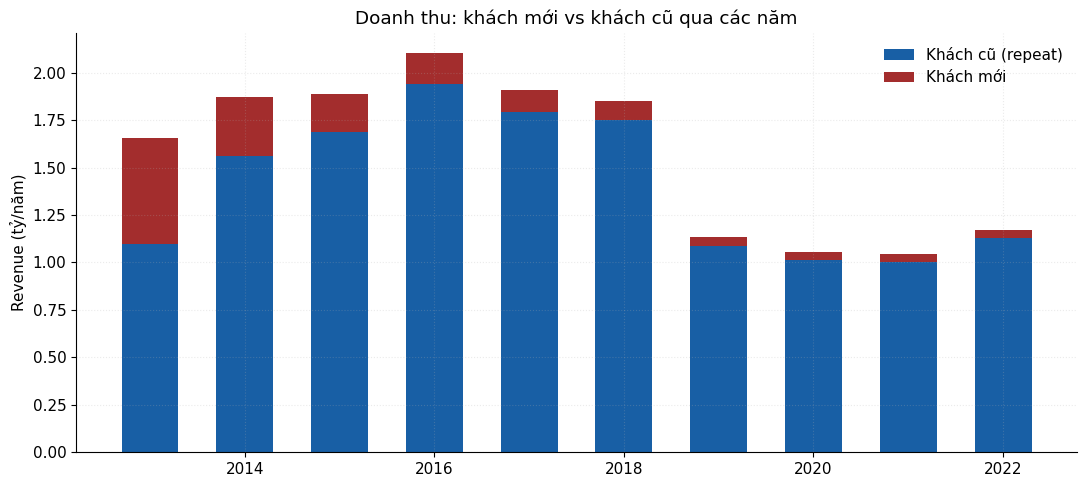

=== 09. Tỷ trọng revenue từ khách cũ (repeat) theo năm ===
  2013: 66.1%  |  2018: 94.7%  |  2019: 95.6%  |  2022: 96.4%



In [6]:
first_order = orders.groupby("customer_id")["order_date"].min().rename("first_order_date")
li2 = li.merge(first_order, on="customer_id", how="left")
li2["cust_type"] = np.where(li2["order_date"] == li2["first_order_date"], "Khách mới", "Khách cũ (repeat)")
nr_yr = li2.groupby(["year", "cust_type"])["line_revenue"].sum().unstack() / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(nr_yr.index, nr_yr["Khách cũ (repeat)"], color=C_COGS, label="Khách cũ (repeat)", width=0.6)
ax.bar(nr_yr.index, nr_yr["Khách mới"], bottom=nr_yr["Khách cũ (repeat)"], color=C_REV, label="Khách mới", width=0.6)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu: khách mới vs khách cũ qua các năm")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "09_new_vs_repeat.png", dpi=110); plt.show(); plt.close(fig)

repeat_share = (nr_yr["Khách cũ (repeat)"] / nr_yr.sum(axis=1) * 100)
print("=== 09. Tỷ trọng revenue từ khách cũ (repeat) theo năm ===")
print(f"  2013: {repeat_share.loc[2013]:.1f}%  |  2018: {repeat_share.loc[2018]:.1f}%  |  "
      f"2019: {repeat_share.loc[2019]:.1f}%  |  2022: {repeat_share.loc[2022]:.1f}%\n")

**Phân tích chart 09 — Khách mới vs khách cũ (repeat)**

1. **Thể hiện gì:** cột chồng, doanh thu theo năm tách 2 lát: khách mới (đơn đầu tiên) và khách cũ (đơn lặp lại).
2. **Insight:** tỷ trọng doanh thu từ khách cũ tăng 66.1% (2013) → 94.7% (2018) → 96.4% (2022); nhìn tổng chiều cao cột, doanh thu từ khách MỚI gần như biến mất sau 2019 (từ ~0.3-0.5 tỷ/năm xuống dưới 0.1 tỷ).
3. **Lưu ý:** tỷ trọng khách cũ tăng theo tenure tích lũy là hiện tượng tự nhiên (pool khách càng lớn theo thời gian) — KHÔNG phải bằng chứng lòng trung thành, vì tần suất mua trung bình toàn kỳ chỉ 1.83 đơn/khách; nên đọc "khách mới biến mất" (dấu hiệu acquisition sụp đổ) hơn là "% khách cũ tăng".


## 10. WATERFALL — Gross booked -> Net thực thu

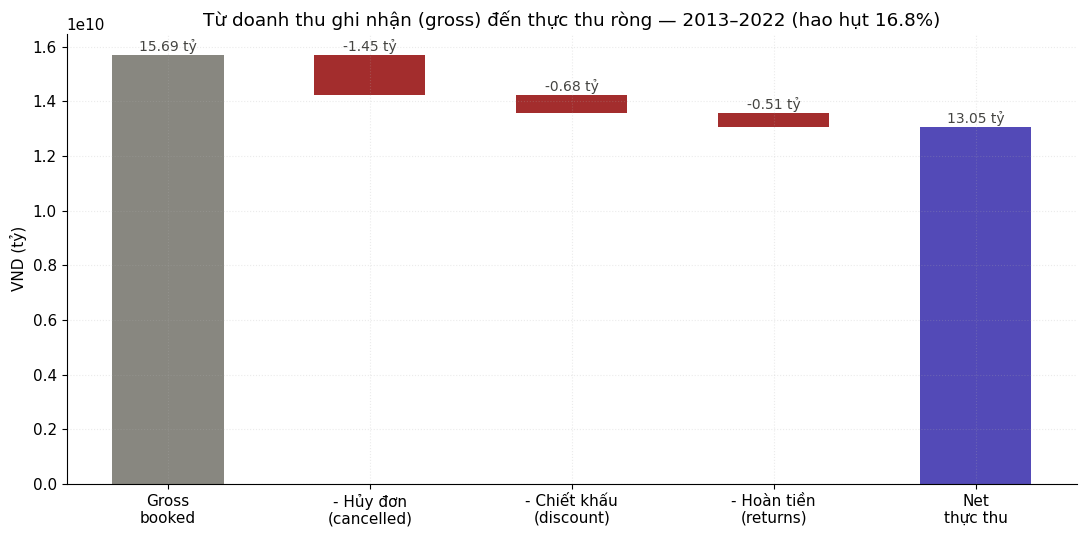

=== 10. Waterfall Gross -> Net (toàn kỳ 2013-2022, tỷ VND) ===
  Gross booked      :    15.69
  - Hủy đơn         :    -1.45  (9.2%)
  - Chiết khấu      :    -0.68  (4.3%)
  - Hoàn tiền       :    -0.51  (3.3%)
  = Net thực thu    :    13.05  (83.2% của gross)



In [7]:
gross = li["line_revenue"].sum()
cancelled_loss = li.loc[li["order_status"] == "cancelled", "line_revenue"].sum()
after_cancel = gross - cancelled_loss
discount_loss = li.loc[li["order_status"] != "cancelled", "discount_amount"].sum()
after_discount = after_cancel - discount_loss
refund_loss = returns["refund_amount"].sum()
net_final = after_discount - refund_loss

stages = ["Gross\nbooked", "- Hủy đơn\n(cancelled)", "- Chiết khấu\n(discount)", "- Hoàn tiền\n(returns)", "Net\nthực thu"]
values = [gross, -cancelled_loss, -discount_loss, -refund_loss, net_final]
cum = [gross, after_cancel, after_discount, net_final, net_final]
starts = [0, after_cancel, after_discount, net_final, 0]

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = [C_GRAY, C_REV, C_REV, C_REV, C_ACCENT]
bar_bottoms = [0, after_cancel, after_discount, net_final, 0]
bar_heights = [gross, cancelled_loss, discount_loss, refund_loss, net_final]
for i, (s, h, c) in enumerate(zip(bar_bottoms, bar_heights, colors)):
    ax.bar(i, h, bottom=s, color=c, width=0.55)
    label = f"{(values[i] if i not in (0,4) else cum[i])/1e9:+.2f} tỷ" if i not in (0, 4) else f"{cum[i]/1e9:.2f} tỷ"
    ax.text(i, s + h + gross * 0.01, label, ha="center", fontsize=10, color="#444441")
ax.set_xticks(range(5), stages)
ax.set_ylabel("VND (tỷ)")
ax.set_title(f"Từ doanh thu ghi nhận (gross) đến thực thu ròng — 2013–2022 (hao hụt {(1-net_final/gross)*100:.1f}%)")
fig.tight_layout(); fig.savefig(OUT / "10_waterfall_net_revenue.png", dpi=110); plt.show(); plt.close(fig)

print("=== 10. Waterfall Gross -> Net (toàn kỳ 2013-2022, tỷ VND) ===")
print(f"  Gross booked      : {gross/1e9:8.2f}")
print(f"  - Hủy đơn         : {-cancelled_loss/1e9:8.2f}  ({cancelled_loss/gross*100:.1f}%)")
print(f"  - Chiết khấu      : {-discount_loss/1e9:8.2f}  ({discount_loss/gross*100:.1f}%)")
print(f"  - Hoàn tiền       : {-refund_loss/1e9:8.2f}  ({refund_loss/gross*100:.1f}%)")
print(f"  = Net thực thu    : {net_final/1e9:8.2f}  ({net_final/gross*100:.1f}% của gross)\n")

**Phân tích chart 10 — Waterfall Gross booked → Net thực thu**

1. **Thể hiện gì:** waterfall 4 bước từ Gross booked (100%) → trừ Hủy đơn → trừ Chiết khấu → trừ Hoàn tiền → Net thực thu.
2. **Insight:** Gross 15.69 tỷ VND → Net thực thu **13.05 tỷ VND (83.2%)**. Đòn bẩy lớn nhất là hủy đơn (-9.2%, -1.45 tỷ), gấp đôi discount (-4.3%, -0.68 tỷ), gần gấp 3 lần refund (-3.3%, -0.51 tỷ).
3. **Lưu ý:** "Revenue" trong `sales.csv` (dùng làm target Phần B) là số Gross booked — không phải tiền thực về; waterfall này chỉ để hiểu bối cảnh kinh doanh, KHÔNG áp dụng cắt giảm 16.8% này vào forecast Revenue/COGS (2 khái niệm phục vụ 2 mục đích khác nhau).


## 11. REVENUE THEO KÊNH (order_source) QUA CÁC NĂM

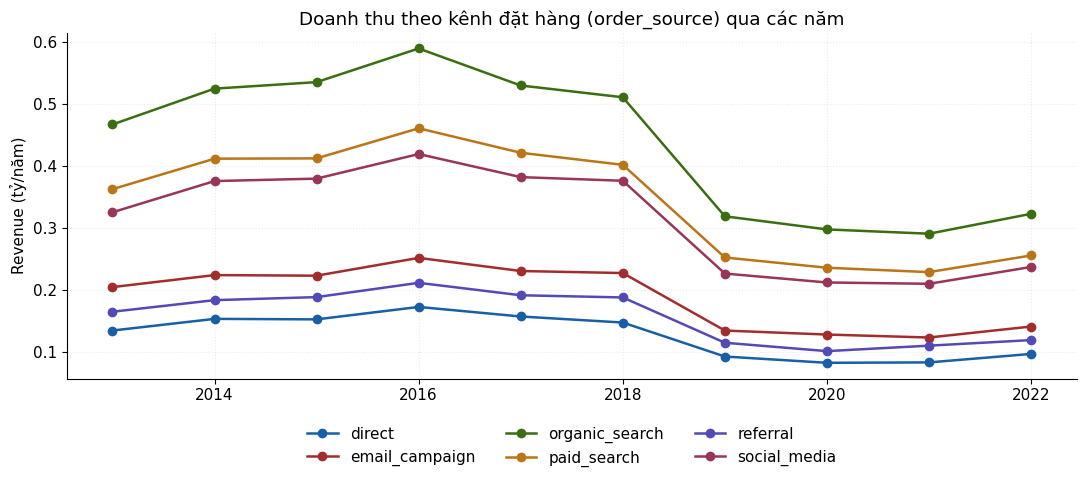

=== 11. Kênh order_source (tỷ VND, 2022) ===
  {'direct': 0.1, 'email_campaign': 0.1, 'organic_search': 0.3, 'paid_search': 0.3, 'referral': 0.1, 'social_media': 0.2}



In [8]:
src_yr = li.groupby(["year", "order_source"])["line_revenue"].sum().unstack() / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
for i, src in enumerate(src_yr.columns):
    ax.plot(src_yr.index, src_yr[src], "o-", color=PALETTE[i % len(PALETTE)], lw=1.8, label=src)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu theo kênh đặt hàng (order_source) qua các năm")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(); fig.savefig(OUT / "11_channel_trend.png", dpi=110); plt.show(); plt.close(fig)

print("=== 11. Kênh order_source (tỷ VND, 2022) ===")
print(f"  {src_yr.loc[2022].round(1).to_dict()}\n")

**Phân tích chart 11 — Revenue theo kênh (order_source) qua các năm**

1. **Thể hiện gì:** doanh thu theo năm, tách theo 6 kênh order_source (organic_search, paid_search, social_media, email_campaign, referral, direct).
2. **Insight:** toàn bộ 6 kênh đều gãy cùng lúc năm 2019 (VD organic_search 0.51→0.32 tỷ, paid_search 0.40→0.25 tỷ) — xác nhận break là vấn đề hệ thống/retention, không phải 1 kênh cụ thể suy yếu.
3. **Lưu ý:** chart chỉ nhìn doanh thu theo kênh, không tách được nguyên nhân "vì sao" (đã điều tra sâu hơn ở chart 34 — margin theo kênh cũng đồng đều); không suy diễn thêm về hiệu quả marketing ROI (thiếu dữ liệu chi phí).


## 12. GIÁ TRỊ KHÁCH HÀNG THEO ACQUISITION_CHANNEL (kênh nào "câu" khách xịn)

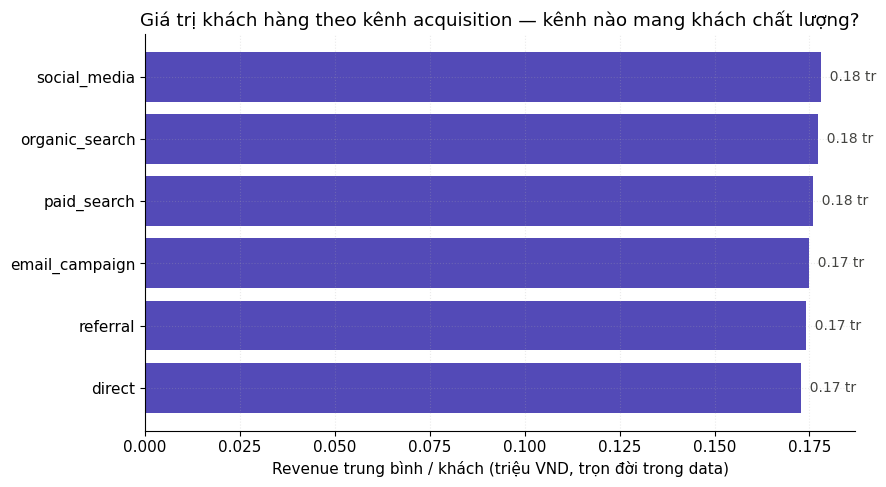

=== 12. LTV theo acquisition_channel (triệu VND/khách) ===
  {'direct': 0.17, 'referral': 0.17, 'email_campaign': 0.17, 'paid_search': 0.18, 'organic_search': 0.18, 'social_media': 0.18}



In [9]:
cust_rev = li.groupby("customer_id")["line_revenue"].sum().rename("total_revenue")
cust_ch = customers.set_index("customer_id")["acquisition_channel"]
ltv = cust_rev.to_frame().join(cust_ch).groupby("acquisition_channel")["total_revenue"].mean().sort_values() / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(ltv.index, ltv.values, color=C_ACCENT)
for i, v in enumerate(ltv.values):
    ax.text(v, i, f"  {v:.2f} tr", va="center", fontsize=10, color="#444441")
ax.set_xlabel("Revenue trung bình / khách (triệu VND, trọn đời trong data)")
ax.set_title("Giá trị khách hàng theo kênh acquisition — kênh nào mang khách chất lượng?")
fig.tight_layout(); fig.savefig(OUT / "12_ltv_by_channel.png", dpi=110); plt.show(); plt.close(fig)

print("=== 12. LTV theo acquisition_channel (triệu VND/khách) ===")
print(f"  {ltv.round(2).to_dict()}\n")

**Phân tích chart 12 — LTV theo acquisition_channel**

1. **Thể hiện gì:** LTV trung bình/khách (triệu VND) theo acquisition_channel.
2. **Insight:** gần như bằng nhau giữa mọi kênh (0.17-0.18 triệu VND/khách), chênh lệch kênh cao nhất/thấp nhất chỉ ~6%.
3. **Lưu ý:** acquisition_channel KHÔNG phải yếu tố phân hoá chất lượng khách trong dữ liệu này — không dùng chart này để biện minh ưu tiên ngân sách theo kênh "khách xịn hơn"; nên tối ưu theo chi phí acquisition (rẻ hơn) thay vì kỳ vọng khác biệt chất lượng khách.


## 13. REVENUE THEO PAYMENT_METHOD QUA CÁC NĂM (tỷ trọng)

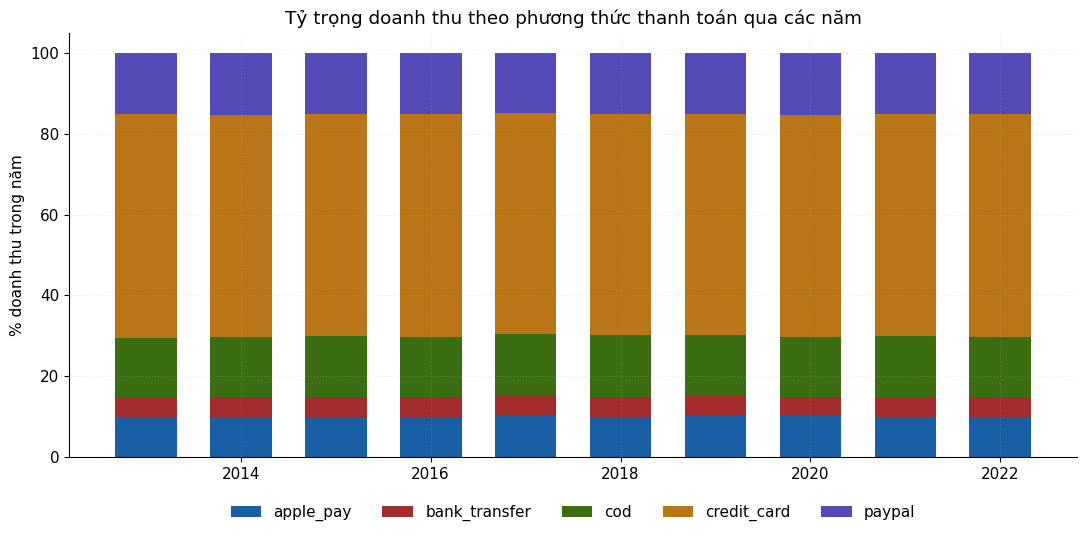

=== 13. Payment method ===
  2013: {'apple_pay': 9.8, 'bank_transfer': 4.9, 'cod': 14.9, 'credit_card': 55.2, 'paypal': 15.2}
  2022: {'apple_pay': 9.9, 'bank_transfer': 5.1, 'cod': 14.9, 'credit_card': 55.2, 'paypal': 15.0}



In [10]:
pay_yr = li.groupby(["year", "payment_method"])["line_revenue"].sum().unstack()
pay_share = pay_yr.div(pay_yr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(pay_share))
for i, pm in enumerate(pay_share.columns):
    ax.bar(pay_share.index, pay_share[pm], bottom=bottom, label=pm,
           color=PALETTE[i % len(PALETTE)], width=0.65)
    bottom += pay_share[pm].values
ax.set_ylabel("% doanh thu trong năm")
ax.set_title("Tỷ trọng doanh thu theo phương thức thanh toán qua các năm")
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(); fig.savefig(OUT / "13_payment_method_share.png", dpi=110); plt.show(); plt.close(fig)

print("=== 13. Payment method ===")
print(f"  2013: {pay_share.loc[2013].round(1).to_dict()}")
print(f"  2022: {pay_share.loc[2022].round(1).to_dict()}\n")

**Phân tích chart 13 — Payment method share qua các năm**

1. **Thể hiện gì:** tỷ trọng % doanh thu theo phương thức thanh toán (credit_card, paypal, cod, apple_pay, bank_transfer) qua các năm.
2. **Insight:** cơ cấu gần như đứng yên suốt 10 năm (credit_card ~55%, paypal ~15%, cod ~15%, apple_pay ~10%, bank_transfer ~5%; 2013 và 2022 lệch nhau <0.5 điểm %).
3. **Lưu ý:** không có dịch chuyển sang thanh toán số theo thời gian — khác kỳ vọng thông thường về e-commerce trưởng thành dần; feature này gần như hằng số nên không đáng đưa vào model forecast Phần B (không mang tín hiệu thời gian).


## 14. KHUYẾN MÃI: AOV promo vs non-promo + revenue theo promo_type

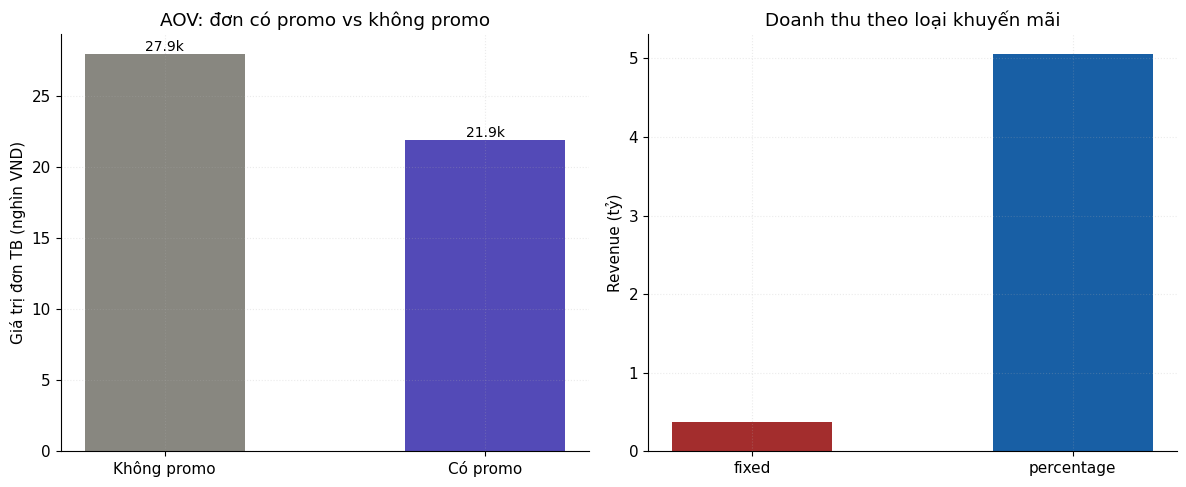

=== 14. Khuyến mãi ===
  AOV không promo: 27,945 VND | AOV có promo: 21,896 VND (chênh -21.6%)
  Revenue theo promo_type (tỷ): {'fixed': 0.38, 'percentage': 5.06}

Đã lưu 8 chart (07-14) vào /Users/lhoanghai_/Documents/Study/Dự án datathon2026/EDA_Insight/output/phase2


In [11]:
li["has_promo"] = li["promo_id"].notna()
order_val = li.groupby(["order_id", "has_promo"])["line_revenue"].sum().reset_index()
aov = order_val.groupby("has_promo")["line_revenue"].mean()

promo_type_rev = li[li["has_promo"]].groupby("promo_type")["line_revenue"].sum() / 1e9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(["Không promo", "Có promo"], aov.values / 1e3, color=[C_GRAY, C_ACCENT], width=0.5)
for i, v in enumerate(aov.values / 1e3):
    ax1.text(i, v, f"{v:.1f}k", ha="center", va="bottom", fontsize=10)
ax1.set_ylabel("Giá trị đơn TB (nghìn VND)")
ax1.set_title("AOV: đơn có promo vs không promo")

ax2.bar(promo_type_rev.index, promo_type_rev.values, color=[C_REV, C_COGS], width=0.5)
ax2.set_ylabel("Revenue (tỷ)")
ax2.set_title("Doanh thu theo loại khuyến mãi")
fig.tight_layout(); fig.savefig(OUT / "14_promo_effect.png", dpi=110); plt.show(); plt.close(fig)

print("=== 14. Khuyến mãi ===")
print(f"  AOV không promo: {aov[False]:,.0f} VND | AOV có promo: {aov[True]:,.0f} VND "
      f"(chênh {(aov[True]/aov[False]-1)*100:+.1f}%)")
print(f"  Revenue theo promo_type (tỷ): {promo_type_rev.round(2).to_dict()}\n")

print(f"Đã lưu 8 chart (07-14) vào {OUT}")

**Phân tích chart 14 — Hiệu ứng khuyến mãi (AOV + doanh thu theo promo_type)**

1. **Thể hiện gì:** so sánh AOV đơn có/không promo, và doanh thu theo loại promo (percentage vs fixed).
2. **Insight:** AOV không promo 27,945 VND vs AOV có promo 21,896 VND (**thấp hơn 21.6%** — ngược trực giác, promo thường kỳ vọng đẩy giá trị giỏ hàng lên); doanh thu promo "percentage" áp đảo "fixed" (5.06 tỷ vs 0.38 tỷ) nhưng cũng vì có 45 promo percentage so với chỉ 5 promo fixed.
3. **Lưu ý:** chênh lệch doanh thu percentage vs fixed KHÔNG phản ánh loại nào "hiệu quả hơn" trên cùng 1 đơn vị promo (số lượng promo mỗi loại rất khác nhau); cần điều tra thêm (ngoài scope diagnostic) — có thể promo đang dùng cho hàng thanh lý/giá thấp thay vì kích cầu giỏ hàng lớn, chưa kết luận vội promo "không hiệu quả".


## PHẦN MỞ RỘNG — Giai đoạn 2 chính thức (2026-07-20, DA) Trả lời 5 câu hỏi Diagnostic bắt buộc (xem PROGRESS.md #2 + đề bài task): Q1 (15-16) vì sao 2019-2021 sụt mạnh — tách giá/khối lượng/promo Q2 (17-18) cơ chế lỗ gộp — unit_price vs catalog cost, đối chiếu promo Q3 (19)    margin category/region — kiểm soát biến nhiễu mix Q4 (20)    marketing channel (order_source) — revenue+margin theo năm Q5 (21)    Tết x cường độ khuyến mãi Export CSV vào phase2_diagnostic/data/ (trước đây để trống có chủ đích — xem DATA_LINEAGE.md). Chart mới đánh số tiếp 29-35 (không đè 07-14 đã có).

In [12]:
DATA_OUT = HERE / "data"
DATA_OUT.mkdir(parents=True, exist_ok=True)

## 15. Q1 — VÌ SAO 2019-2021 SỤT MẠNH? Tách ASP (giá) vs qty/orders/khách (khối lượng)

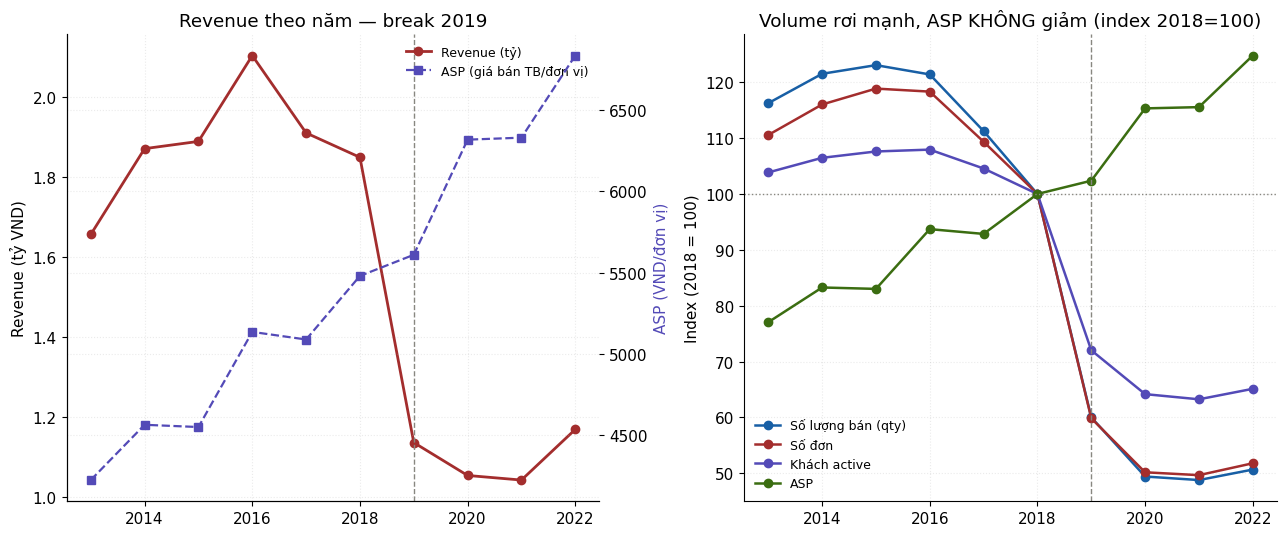

=== 15. Q1 — Decompose YoY 2018→2019 ===
  Revenue -38.6% | ASP +2.4% | Qty -40.0% | Số đơn -40.2% | Khách active -28.0% | AOV +2.7%
  -> ASP KHÔNG giảm (thậm chí tăng nhẹ); sụt giảm gần như toàn bộ đến từ khối lượng (qty/số đơn) rơi ~40%, khách active rơi ~28%.



In [13]:
yr_kpi = li.groupby("year").agg(revenue=("line_revenue", "sum"), qty=("quantity", "sum")).reset_index()
yr_kpi["ASP"] = yr_kpi["revenue"] / yr_kpi["qty"]

ord_all = orders.assign(year=orders["order_date"].dt.year)
ord_all = ord_all[ord_all["year"].between(2013, 2022)]
n_orders = ord_all.groupby("year")["order_id"].nunique().rename("n_orders")
n_active_cust = ord_all.groupby("year")["customer_id"].nunique().rename("n_active_cust")
yr_kpi = yr_kpi.merge(n_orders, on="year").merge(n_active_cust, on="year")
yr_kpi["AOV"] = yr_kpi["revenue"] / yr_kpi["n_orders"]
yr_kpi.to_csv(DATA_OUT / "yearly_kpi_decompose.csv", index=False)

base = yr_kpi.set_index("year")
r18, r19 = base.loc[2018], base.loc[2019]
d_revenue = (r19["revenue"] / r18["revenue"] - 1) * 100
d_asp = (r19["ASP"] / r18["ASP"] - 1) * 100
d_qty = (r19["qty"] / r18["qty"] - 1) * 100
d_orders = (r19["n_orders"] / r18["n_orders"] - 1) * 100
d_cust = (r19["n_active_cust"] / r18["n_active_cust"] - 1) * 100
d_aov = (r19["AOV"] / r18["AOV"] - 1) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
idx = base.index
ax1.plot(idx, base["revenue"] / 1e9, "o-", color=C_REV, lw=2, label="Revenue (tỷ)")
ax1.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax1.set_ylabel("Revenue (tỷ VND)"); ax1.set_title("Revenue theo năm — break 2019")
ax1b = ax1.twinx()
ax1b.plot(idx, base["ASP"], "s--", color=C_ACCENT, lw=1.6, label="ASP (giá bán TB/đơn vị)")
ax1b.set_ylabel("ASP (VND/đơn vị)", color=C_ACCENT)
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, frameon=False, loc="upper right", fontsize=9)

idx100 = base / base.loc[2018] * 100
for col, c, lbl in [("qty", C_COGS, "Số lượng bán (qty)"), ("n_orders", C_REV, "Số đơn"),
                     ("n_active_cust", C_ACCENT, "Khách active"), ("ASP", "#3B6D11", "ASP")]:
    ax2.plot(idx, idx100[col], "o-", color=c, lw=1.8, label=lbl)
ax2.axhline(100, color=C_GRAY, ls=":", lw=1)
ax2.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax2.set_ylabel("Index (2018 = 100)"); ax2.set_title("Volume rơi mạnh, ASP KHÔNG giảm (index 2018=100)")
ax2.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(OUT / "29_yearly_price_volume_decompose.png", dpi=110); plt.show(); plt.close(fig)

print("=== 15. Q1 — Decompose YoY 2018→2019 ===")
print(f"  Revenue {d_revenue:+.1f}% | ASP {d_asp:+.1f}% | Qty {d_qty:+.1f}% | "
      f"Số đơn {d_orders:+.1f}% | Khách active {d_cust:+.1f}% | AOV {d_aov:+.1f}%")
print("  -> ASP KHÔNG giảm (thậm chí tăng nhẹ); sụt giảm gần như toàn bộ đến từ khối lượng"
      " (qty/số đơn) rơi ~40%, khách active rơi ~28%.\n")

**Phân tích chart 29 — Decompose giá (ASP) vs khối lượng (qty) theo năm**

1. **Thể hiện gì:** decompose Revenue = qty × ASP theo năm, cùng số đơn và khách active — so sánh 2018 vs 2019.
2. **Insight:** Revenue **-38.6%** (2018→2019) nhưng ASP **+2.4%**, AOV **+2.7%** (TĂNG chứ không giảm); ngược lại qty **-40.0%**, số đơn **-40.2%**, khách active **-28.0%**. → Bác bỏ giả thuyết "giảm giá gây break" — nguyên nhân là khối lượng giao dịch sụp đổ (ít đơn, ít khách), không phải giá bán.
3. **Lưu ý:** đây là so sánh 2 điểm dữ liệu (2018 vs 2019), không phải hồi quy xu hướng đầy đủ — dùng để mô tả HƯỚNG đi (khối lượng vs giá), không dùng để ngoại suy chính xác mức độ sụt giảm các năm khác.


## 16. Q1(c) — CƯỜNG ĐỘ KHUYẾN MÃI THEO NĂM (join order_items + promotions qua promo_id, FK sạch 100%)

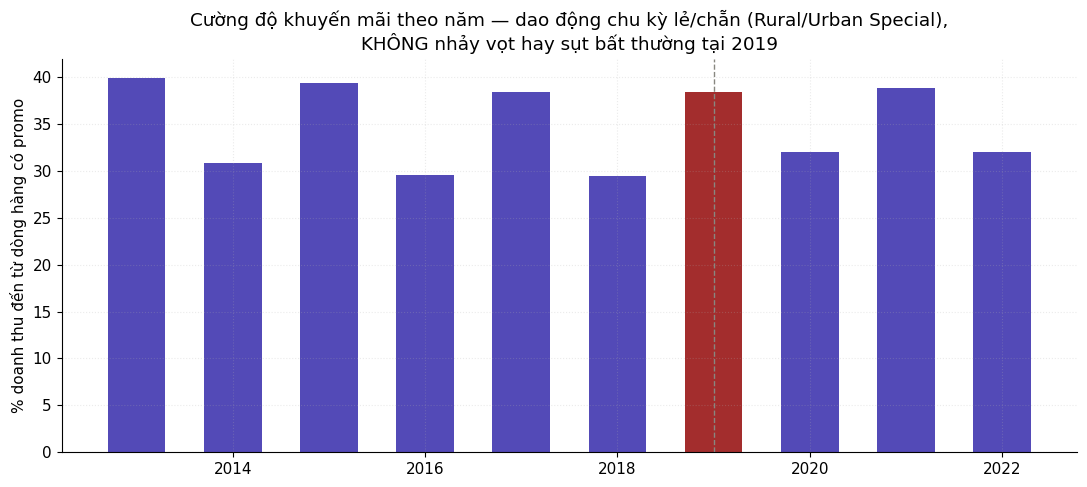

=== 16. Q1(c) — Cường độ khuyến mãi theo năm (% doanh thu có promo) ===
{2013: 39.9, 2014: 30.8, 2015: 39.4, 2016: 29.5, 2017: 38.4, 2018: 29.4, 2019: 38.4, 2020: 32.0, 2021: 38.9, 2022: 32.0}
  n_promo_active_overlap theo năm: {2013: 6, 2014: 5, 2015: 7, 2016: 5, 2017: 7, 2018: 5, 2019: 7, 2020: 5, 2021: 7, 2022: 5}
  -> 2019 (38.4%) nằm đúng nhịp năm lẻ (2013/2015/2017/2019/2021 ~38-40%, năm chẵn ~30-32%) — mix/cường độ promo KHÔNG phải nguyên nhân break.



In [14]:
li["has_promo"] = li["promo_id"].notna()
promo_line_rev = li.loc[li["has_promo"]].groupby("year")["line_revenue"].sum()
total_rev_yr = li.groupby("year")["line_revenue"].sum()
avg_discount_active = li.loc[li["has_promo"]].groupby("year")["discount_value"].mean()

promo_rev = pd.DataFrame({
    "pct_revenue_with_promo": (promo_line_rev / total_rev_yr * 100),
    "pct_lineitems_with_promo": li.groupby("year")["has_promo"].mean() * 100,
    "avg_discount_value_active_pct": avg_discount_active,
})
active_counts = {}
for y in range(2013, 2023):
    y_start, y_end = pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y}-12-31")
    active_counts[y] = int(((promotions["start_date"] <= y_end) & (promotions["end_date"] >= y_start)).sum())
promo_rev["n_promo_active_overlap"] = pd.Series(active_counts)
promo_rev.index.name = "year"
promo_rev.reset_index().to_csv(DATA_OUT / "promo_intensity_by_year.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [C_ACCENT if y != 2019 else C_REV for y in promo_rev.index]
ax.bar(promo_rev.index, promo_rev["pct_revenue_with_promo"], color=colors, width=0.6)
ax.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax.set_ylabel("% doanh thu đến từ dòng hàng có promo")
ax.set_title("Cường độ khuyến mãi theo năm — dao động chu kỳ lẻ/chẵn (Rural/Urban Special),\nKHÔNG nhảy vọt hay sụt bất thường tại 2019")
fig.tight_layout(); fig.savefig(OUT / "30_promo_intensity_by_year.png", dpi=110); plt.show(); plt.close(fig)

print("=== 16. Q1(c) — Cường độ khuyến mãi theo năm (% doanh thu có promo) ===")
print(promo_rev["pct_revenue_with_promo"].round(1).to_dict())
print(f"  n_promo_active_overlap theo năm: {active_counts}")
print("  -> 2019 (38.4%) nằm đúng nhịp năm lẻ (2013/2015/2017/2019/2021 ~38-40%,"
      " năm chẵn ~30-32%) — mix/cường độ promo KHÔNG phải nguyên nhân break.\n")

**Phân tích chart 30 — Cường độ khuyến mãi theo năm**

1. **Thể hiện gì:** % doanh thu có promo theo từng năm 2013-2022.
2. **Insight:** dao động theo chu kỳ năm lẻ/chẵn (năm lẻ ~38-40% do có thêm "Rural Special"/"Urban Blowout", năm chẵn ~29-32%); **2019 = 38.4%**, đúng nhịp năm lẻ bình thường, KHÔNG bất thường → loại bỏ giả thuyết "đổi mix/cường độ promotion gây break 2019".
3. **Lưu ý:** chart chỉ đo % doanh thu có promo, không đo GIÁ TRỊ giảm giá — 1 năm có cùng % doanh thu promo vẫn có thể khác nhau về mức giảm giá sâu/nông; kết luận "không bất thường" chỉ áp dụng cho tần suất, không phải cường độ giảm giá (xem chart 31 cho khía cạnh đó).


## 17. Q2 — CƠ CHẾ LỖ GỘP: unit_price/catalog price theo tháng, đối chiếu promotion đang chạy

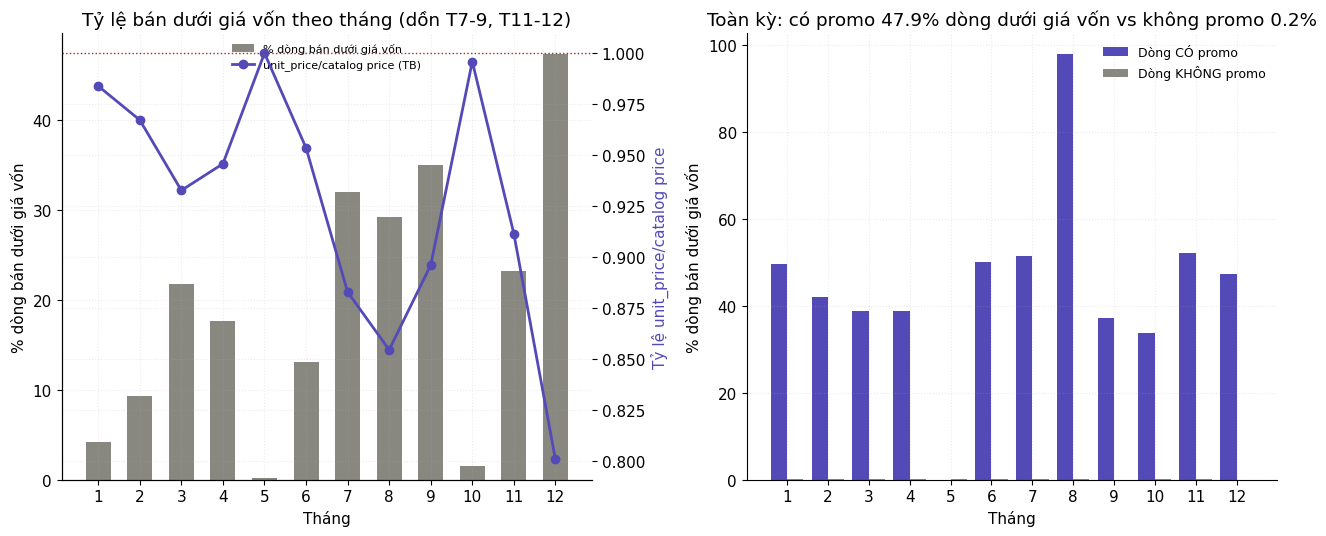

=== 17. Q2 — Cơ chế lỗ gộp: promotion là nguyên nhân trực tiếp ===
  % dòng bán dưới giá vốn KHI có promo   : 47.86%
  % dòng bán dưới giá vốn KHI KHÔNG có promo: 0.18%
  4 tháng lỗ nhiều dòng nhất: [{'month': 12, 'pct_below_cost': 47.29409127421494}, {'month': 9, 'pct_below_cost': 34.925128979489116}, {'month': 7, 'pct_below_cost': 31.930357258220816}, {'month': 8, 'pct_below_cost': 29.234938826080224}]



In [15]:
li["below_cost"] = li["unit_price"] < li["cogs"]
li["price_ratio"] = li["unit_price"] / li["price"]

mo = li.groupby("month").agg(
    mean_price_ratio=("price_ratio", "mean"),
    median_price_ratio=("price_ratio", "median"),
    pct_below_cost=("below_cost", "mean"),
).reset_index()
mo["pct_below_cost"] *= 100
bc_by_promo = li.groupby(["month", "has_promo"])["below_cost"].mean().unstack() * 100
mo["pct_below_cost_with_promo"] = mo["month"].map(bc_by_promo[True])
mo["pct_below_cost_without_promo"] = mo["month"].map(bc_by_promo[False])

promo_days_by_month = []
for m in range(1, 13):
    days = sum(len(pd.date_range(p.start_date, p.end_date, freq="D")[pd.date_range(p.start_date, p.end_date, freq="D").month == m])
               for _, p in promotions.iterrows())
    promo_days_by_month.append(days)
mo["promo_active_days_sum_alltime"] = promo_days_by_month
mo.to_csv(DATA_OUT / "monthly_unit_price_ratio.csv", index=False)

overall_bc_promo = li.loc[li["has_promo"], "below_cost"].mean() * 100
overall_bc_nopromo = li.loc[~li["has_promo"], "below_cost"].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
ax1.bar(mo["month"], mo["pct_below_cost"], color=C_GRAY, width=0.6, label="% dòng bán dưới giá vốn")
ax1b = ax1.twinx()
ax1b.plot(mo["month"], mo["mean_price_ratio"], "o-", color=C_ACCENT, lw=2, label="unit_price/catalog price (TB)")
ax1b.axhline(1.0, color=C_REV, ls=":", lw=1)
ax1.set_xticks(range(1, 13)); ax1.set_xlabel("Tháng"); ax1.set_ylabel("% dòng bán dưới giá vốn")
ax1b.set_ylabel("Tỷ lệ unit_price/catalog price", color=C_ACCENT)
ax1.set_title("Tỷ lệ bán dưới giá vốn theo tháng (dồn T7-9, T11-12)")
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, frameon=False, fontsize=8, loc="upper center")

ax2.bar(mo["month"] - 0.2, mo["pct_below_cost_with_promo"], width=0.4, color=C_ACCENT, label="Dòng CÓ promo")
ax2.bar(mo["month"] + 0.2, mo["pct_below_cost_without_promo"], width=0.4, color=C_GRAY, label="Dòng KHÔNG promo")
ax2.set_xticks(range(1, 13)); ax2.set_xlabel("Tháng"); ax2.set_ylabel("% dòng bán dưới giá vốn")
ax2.set_title(f"Toàn kỳ: có promo {overall_bc_promo:.1f}% dòng dưới giá vốn vs không promo {overall_bc_nopromo:.1f}%")
ax2.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(OUT / "31_unit_price_ratio_by_month.png", dpi=110); plt.show(); plt.close(fig)

print("=== 17. Q2 — Cơ chế lỗ gộp: promotion là nguyên nhân trực tiếp ===")
print(f"  % dòng bán dưới giá vốn KHI có promo   : {overall_bc_promo:.2f}%")
print(f"  % dòng bán dưới giá vốn KHI KHÔNG có promo: {overall_bc_nopromo:.2f}%")
top4 = mo.sort_values("pct_below_cost", ascending=False)[["month", "pct_below_cost"]].head(4)
print(f"  4 tháng lỗ nhiều dòng nhất: {top4.to_dict('records')}\n")

**Phân tích chart 31 — Tỷ lệ unit_price/catalog theo tháng + cơ chế lỗ gộp**

1. **Thể hiện gì:** tỷ lệ unit_price/catalog price trung bình theo tháng, đối chiếu % dòng bán dưới giá vốn có/không promo.
2. **Insight:** dòng CÓ promo bán dưới giá vốn **47.86%** vs dòng KHÔNG promo chỉ **0.18%** (chênh ~266 lần) — bằng chứng trực tiếp khuyến mãi là cơ chế gây lỗ gộp. Theo tháng, tỷ lệ dưới giá vốn cao nhất T12 (47.3%), T9 (34.9%), T7 (31.9%), T8 (29.2%) — trùng khớp lịch chạy Year-End Sale (T11-T1), Fall Launch (T8-10), Urban Blowout (T7-9); unit_price/catalog rơi xuống 0.80-0.88 đúng các tháng này.
3. **Lưu ý:** đây là bằng chứng cơ chế (mechanism), không phải nguyên nhân break 2019 — break 2019 đã xác định do KHỐI LƯỢNG (chart 29), còn cơ chế lỗ gộp ở đây là vấn đề margin riêng biệt, xảy ra ĐỀU qua các năm (không chỉ 2019) theo đúng lịch promo hàng năm.


## 18. Q2 — TỶ LỆ BÁN DƯỚI GIÁ VỐN THEO CATEGORY — có tập trung Casual/Streetwear?

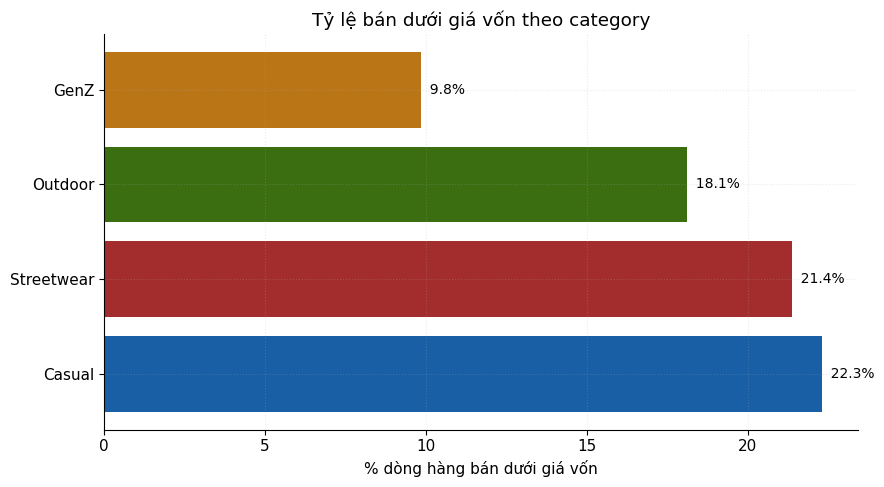

=== 18. Q2 — % dòng bán dưới giá vốn theo category ===
  category  pct_lineitems_below_cost  pct_revenue_below_cost
    Casual                     22.30                   17.93
Streetwear                     21.36                   18.00
   Outdoor                     18.10                   17.20
      GenZ                      9.83                   10.78 



In [16]:
total_rev_by_cat = li.groupby("category")["line_revenue"].sum()
bc_cat = li.groupby("category").agg(
    n_lines=("below_cost", "size"),
    pct_lineitems_below_cost=("below_cost", "mean"),
    revenue_below_cost=("line_revenue", lambda s: s[li.loc[s.index, "below_cost"]].sum()),
).reset_index()
bc_cat["pct_lineitems_below_cost"] *= 100
bc_cat["pct_revenue_below_cost"] = bc_cat.apply(
    lambda r: r["revenue_below_cost"] / total_rev_by_cat[r["category"]] * 100, axis=1)
bc_cat = bc_cat.sort_values("pct_lineitems_below_cost", ascending=False)
bc_cat.to_csv(DATA_OUT / "category_below_cost_rate.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(bc_cat["category"], bc_cat["pct_lineitems_below_cost"], color=PALETTE[:len(bc_cat)])
for i, v in enumerate(bc_cat["pct_lineitems_below_cost"]):
    ax.text(v, i, f"  {v:.1f}%", va="center", fontsize=10)
ax.set_xlabel("% dòng hàng bán dưới giá vốn")
ax.set_title("Tỷ lệ bán dưới giá vốn theo category")
fig.tight_layout(); fig.savefig(OUT / "32_below_cost_rate_by_category.png", dpi=110); plt.show(); plt.close(fig)

print("=== 18. Q2 — % dòng bán dưới giá vốn theo category ===")
print(bc_cat[["category", "pct_lineitems_below_cost", "pct_revenue_below_cost"]].round(2).to_string(index=False), "\n")

**Phân tích chart 32 — % bán dưới giá vốn theo category**

1. **Thể hiện gì:** % dòng bán dưới giá vốn và % doanh thu category đến từ dòng dưới giá vốn, theo 4 category.
2. **Insight:** Casual **22.30%** dòng dưới giá vốn (cao nhất), Streetwear 21.36%, Outdoor 18.10%, GenZ 9.83% (thấp nhất) — xác nhận Casual/Streetwear (2 category margin thấp nhất ở Phase 1) đúng là nơi tập trung bán dưới giá vốn nhiều nhất; vì Streetwear chiếm ~80% doanh thu, riêng 21.36% dòng dưới giá vốn của nó đã đủ kéo margin toàn shop xuống.
3. **Lưu ý:** % dòng dưới giá vốn và % doanh thu-từ-dòng-dưới-giá-vốn là 2 chỉ số khác nhau (GenZ có 9.83% dòng nhưng 10.78% doanh thu từ dòng đó — tỷ lệ không tuyến tính với số dòng vì giá trị dòng khác nhau) — không gộp chung đọc thành 1 con số duy nhất.


## 19. Q3 — MARGIN CATEGORY x REGION: kiểm soát biến nhiễu mix category

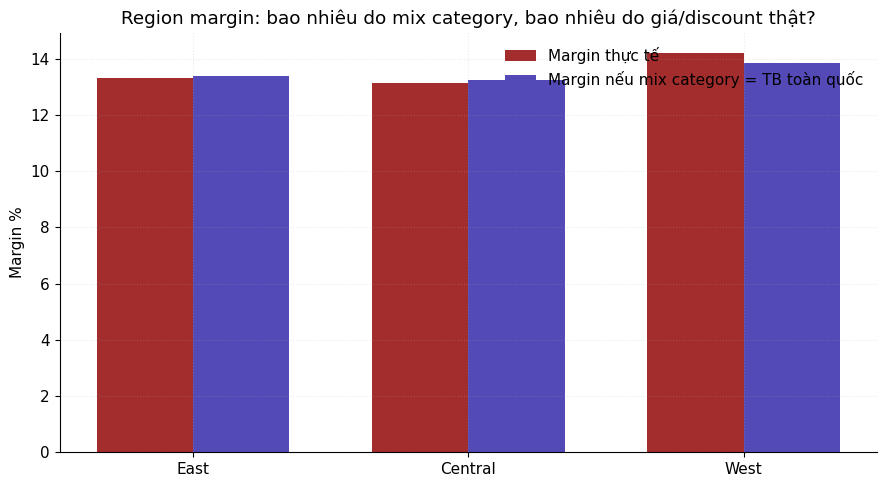

=== 19. Q3 — Margin region: thực tế vs mix-adjusted (trọng số category toàn quốc) ===
 region  actual_margin_pct  mix_adjusted_margin_pct  mix_effect_pp
   East             13.305                   13.376         -0.070
Central             13.148                   13.244         -0.096
   West             14.204                   13.856          0.348 



In [17]:
rc = li.groupby(["region", "category"]).agg(revenue=("line_revenue", "sum"), cogs=("line_cogs", "sum")).reset_index()
rc["margin_pct"] = (rc["revenue"] - rc["cogs"]) / rc["revenue"] * 100
rc["share_in_region_pct"] = rc["revenue"] / rc.groupby("region")["revenue"].transform("sum") * 100
rc.to_csv(DATA_OUT / "category_region_margin_controlled.csv", index=False)

nat_w = li.groupby("category")["line_revenue"].sum()
nat_w = nat_w / nat_w.sum()
region_actual = li.groupby("region").apply(
    lambda g: (g["line_revenue"].sum() - g["line_cogs"].sum()) / g["line_revenue"].sum() * 100,
    include_groups=False)
mix_rows = []
for reg in li["region"].dropna().unique():
    g = li[li["region"] == reg]
    cat_m = g.groupby("category").apply(
        lambda x: (x["line_revenue"].sum() - x["line_cogs"].sum()) / x["line_revenue"].sum() * 100,
        include_groups=False)
    mix_adj = sum(cat_m[c] * nat_w[c] for c in nat_w.index)
    mix_rows.append({"region": reg, "actual_margin_pct": region_actual[reg], "mix_adjusted_margin_pct": mix_adj})
mix_df = pd.DataFrame(mix_rows)
mix_df["mix_effect_pp"] = mix_df["actual_margin_pct"] - mix_df["mix_adjusted_margin_pct"]
mix_df.to_csv(DATA_OUT / "region_margin_mix_decomposition.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(mix_df)); w = 0.35
ax.bar(x - w / 2, mix_df["actual_margin_pct"], w, color=C_REV, label="Margin thực tế")
ax.bar(x + w / 2, mix_df["mix_adjusted_margin_pct"], w, color=C_ACCENT, label="Margin nếu mix category = TB toàn quốc")
ax.set_xticks(x, mix_df["region"])
ax.set_ylabel("Margin %")
ax.set_title("Region margin: bao nhiêu do mix category, bao nhiêu do giá/discount thật?")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "33_category_region_margin_controlled.png", dpi=110); plt.show(); plt.close(fig)

print("=== 19. Q3 — Margin region: thực tế vs mix-adjusted (trọng số category toàn quốc) ===")
print(mix_df.round(3).to_string(index=False), "\n")

**Phân tích chart 33 — Margin category × region: kiểm soát mix**

1. **Thể hiện gì:** margin thực tế vs margin mix-adjusted (kiểm soát cơ cấu category) theo 3 vùng.
2. **Insight:** margin thực tế West 14.20% vs Central 13.15% (chênh 1.06pp); sau khi loại hiệu ứng mix category (áp trọng số toàn quốc), chênh chỉ còn 0.61pp → **~40%** chênh lệch đến từ mix category (West bán nhiều Outdoor hơn — 25.8% doanh thu West là Outdoor vs ~11.5% ở vùng khác), **~60%** còn lại đến từ giá/discount thực sự tốt hơn CÙNG category (VD Outdoor ở West margin 16.74% > Outdoor toàn quốc 16.01%).
3. **Lưu ý:** đây là phương pháp thống kê mô tả (mix-adjustment), CHƯA có kiểm định ý nghĩa thống kê (t-test/CI) cho phần chênh lệch 0.61pp còn lại — kết luận "60% do giá thật" là ước lượng điểm, chưa có khoảng tin cậy, không trích dẫn như con số chính xác tuyệt đối.


## 20. Q4 — MARKETING CHANNEL (order_source): revenue + margin theo năm

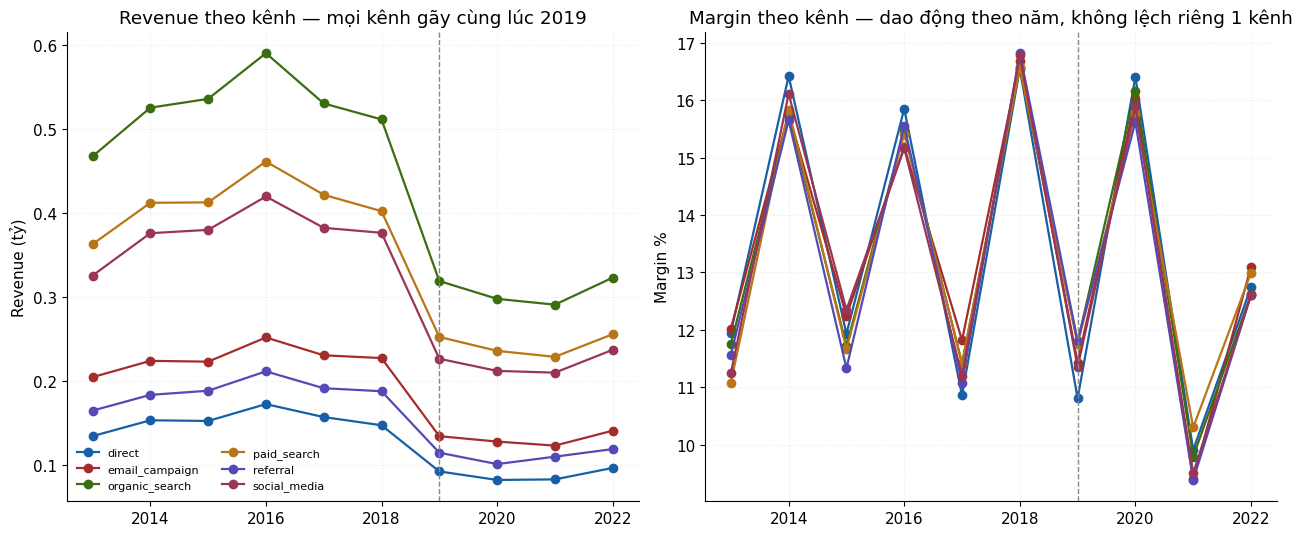

=== 20. Q4 — Sụt giảm revenue 2018→2019 theo kênh (%) ===
{'direct': -37.4, 'email_campaign': -41.0, 'organic_search': -37.7, 'paid_search': -37.3, 'referral': -39.1, 'social_media': -39.9}
  -> Tất cả kênh rơi cùng biên độ (~37-41%) cùng lúc -> break 2019 là vấn đề hệ thống, không phải 1 kênh marketing riêng lẻ suy yếu.



In [18]:
ch = li.groupby(["year", "order_source"]).agg(revenue=("line_revenue", "sum"), cogs=("line_cogs", "sum")).reset_index()
ch["margin_pct"] = (ch["revenue"] - ch["cogs"]) / ch["revenue"] * 100
ch.to_csv(DATA_OUT / "channel_revenue_margin_by_year.csv", index=False)

piv_rev = ch.pivot(index="year", columns="order_source", values="revenue") / 1e9
piv_margin = ch.pivot(index="year", columns="order_source", values="margin_pct")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
for i, c in enumerate(piv_rev.columns):
    ax1.plot(piv_rev.index, piv_rev[c], "o-", color=PALETTE[i % len(PALETTE)], lw=1.6, label=c)
ax1.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax1.set_ylabel("Revenue (tỷ)"); ax1.set_title("Revenue theo kênh — mọi kênh gãy cùng lúc 2019")
ax1.legend(frameon=False, fontsize=8, ncol=2)

for i, c in enumerate(piv_margin.columns):
    ax2.plot(piv_margin.index, piv_margin[c], "o-", color=PALETTE[i % len(PALETTE)], lw=1.6, label=c)
ax2.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax2.set_ylabel("Margin %"); ax2.set_title("Margin theo kênh — dao động theo năm, không lệch riêng 1 kênh")
fig.tight_layout(); fig.savefig(OUT / "34_channel_revenue_margin_trend.png", dpi=110); plt.show(); plt.close(fig)

drop_by_channel = (piv_rev.loc[2019] / piv_rev.loc[2018] - 1) * 100
print("=== 20. Q4 — Sụt giảm revenue 2018→2019 theo kênh (%) ===")
print(drop_by_channel.round(1).to_dict())
print("  -> Tất cả kênh rơi cùng biên độ (~37-41%) cùng lúc -> break 2019 là vấn đề hệ thống,"
      " không phải 1 kênh marketing riêng lẻ suy yếu.\n")

**Phân tích chart 34 — Revenue + margin theo kênh qua các năm**

1. **Thể hiện gì:** doanh thu + margin theo năm, tách theo 6 kênh order_source.
2. **Insight:** mức sụt 2018→2019 giữa các kênh chênh nhau chỉ **3.7 điểm %** (thấp nhất paid_search -37.3%, cao nhất email_campaign -41.0%) — cực kỳ đồng đều; margin theo kênh cũng dao động cùng biên độ theo năm (9-17%), không kênh nào tách khỏi xu hướng chung.
3. **Lưu ý:** đây là xác nhận THÊM (không phải phát hiện mới) cho kết luận đã có ở chart 11 — không đọc như 1 bằng chứng độc lập riêng biệt mà nên xem là lát cắt bổ sung (thêm góc nhìn margin) cho cùng 1 kết luận: break 2019 là vấn đề hệ thống/retention.


## 21. Q5 — TẾT: tương quan biến động doanh thu quanh Tết với cường độ khuyến mãi trùng thời điểm

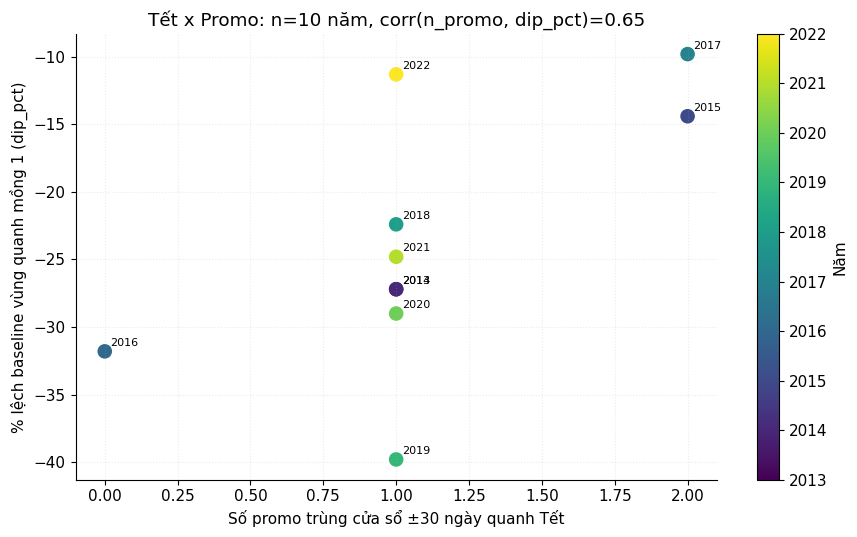

=== 21. Q5 — Tương quan số promo trùng Tết vs biến động doanh thu quanh Tết ===
 year  n_promo_overlap_tet     promo_ids_overlap  dip_pct  pre_week_pct
 2013                    1            PROMO-0006    -27.2         -34.1
 2014                    1            PROMO-0004    -27.2         -35.5
 2015                    2 PROMO-0011;PROMO-0016    -14.4         -19.9
 2016                    0                          -31.8         -36.1
 2017                    2 PROMO-0020;PROMO-0026     -9.8         -42.2
 2018                    1            PROMO-0027    -22.4         -35.0
 2019                    1            PROMO-0036    -39.8          -3.6
 2020                    1            PROMO-0034    -29.0         -47.4
 2021                    1            PROMO-0046    -24.8         -44.4
 2022                    1            PROMO-0044    -11.3         -10.4
  corr(n_promo_overlap_tet, dip_pct) = 0.646 (n=10, mẫu nhỏ — chỉ mang tính gợi ý, KHÔNG kết luận nhân quả)
  corr(n_promo_overl

In [19]:
tet_dates = pd.read_csv(HERE.parent / "phase1_descriptive" / "data" / "tet_dates.csv", parse_dates=["tet_date"])
tet_stats = pd.read_csv(HERE.parent / "phase1_descriptive" / "data" / "tet_yearly_stats.csv")

rows = []
for _, r in tet_stats.iterrows():
    y = int(r["year"])
    tdate = tet_dates.loc[tet_dates["year"] == y, "tet_date"].iloc[0]
    win_start, win_end = tdate - pd.Timedelta(days=30), tdate + pd.Timedelta(days=30)
    overlap = promotions[(promotions["start_date"] <= win_end) & (promotions["end_date"] >= win_start)]
    rows.append({
        "year": y, "tet_date": tdate.date().isoformat(),
        "n_promo_overlap_tet": len(overlap),
        "promo_ids_overlap": ";".join(overlap["promo_id"].tolist()),
        "max_discount_pct_overlap": overlap["discount_value"].max() if len(overlap) else 0.0,
        "dip_pct": r["dip_pct"], "pre_week_pct": r["pre_week_pct"],
    })
tet_promo = pd.DataFrame(rows)
tet_promo.to_csv(DATA_OUT / "tet_promo_overlap.csv", index=False)

corr_dip = tet_promo["n_promo_overlap_tet"].corr(tet_promo["dip_pct"])
corr_pre = tet_promo["n_promo_overlap_tet"].corr(tet_promo["pre_week_pct"])

fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(tet_promo["n_promo_overlap_tet"], tet_promo["dip_pct"], c=tet_promo["year"], cmap="viridis", s=90)
for _, r in tet_promo.iterrows():
    ax.annotate(str(int(r["year"])), (r["n_promo_overlap_tet"], r["dip_pct"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Số promo trùng cửa sổ ±30 ngày quanh Tết")
ax.set_ylabel("% lệch baseline vùng quanh mồng 1 (dip_pct)")
ax.set_title(f"Tết x Promo: n=10 năm, corr(n_promo, dip_pct)={corr_dip:.2f}")
fig.colorbar(sc, label="Năm")
fig.tight_layout(); fig.savefig(OUT / "35_tet_promo_overlap.png", dpi=110); plt.show(); plt.close(fig)

print("=== 21. Q5 — Tương quan số promo trùng Tết vs biến động doanh thu quanh Tết ===")
print(tet_promo[["year", "n_promo_overlap_tet", "promo_ids_overlap", "dip_pct", "pre_week_pct"]].to_string(index=False))
print(f"  corr(n_promo_overlap_tet, dip_pct) = {corr_dip:.3f} (n=10, mẫu nhỏ — chỉ mang tính gợi ý, KHÔNG kết luận nhân quả)")
print(f"  corr(n_promo_overlap_tet, pre_week_pct) = {corr_pre:.3f}\n")

print(f"Đã lưu 7 chart mới (29-35) vào {OUT}")
print(f"Đã export 8 CSV vào {DATA_OUT}")

**Phân tích chart 35 — Tết × cường độ khuyến mãi**

1. **Thể hiện gì:** đối chiếu số promo trùng cửa sổ ±30 ngày quanh Tết mỗi năm với mức lệch baseline (dip_pct, pre_week_pct).
2. **Insight:** `corr(n_promo_overlap_tet, dip_pct) = +0.646` (n=10) — có promo chạy quanh Tết đi cùng dip NHẸ hơn (promo có thể bù đắp phần nào sụt giảm mùa thấp điểm); corr với pre_week_pct chỉ +0.065 — gần như không liên hệ. 2019 là ngoại lệ: chỉ 1 promo nhưng dip sâu nhất (-39.8%), trong khi pre-week lại nhẹ nhất (-3.6%).
3. **Lưu ý:** n=10 năm là mẫu RẤT NHỎ — hệ số tương quan 0.646 dao động rất mạnh chỉ với 1-2 điểm dữ liệu đổi khác, KHÔNG đủ để kết luận nhân quả; case 2019 nhiều khả năng là ảnh hưởng lan từ break 2019 tổng thể hơn là do bản thân promo quanh Tết năm đó — không dùng tương quan này làm căn cứ quyết định ngân sách promo dịp Tết.
